In [68]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import re

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
PROJECT_ROOT = Path.cwd().resolve()

RAW_DIR = PROJECT_ROOT / "Raw_Dataset"
PROCESSED_DIR = PROJECT_ROOT / "Processed_Dataset"
TABLE_DIR = PROJECT_ROOT / "Outputs" / "Tables"
FIGURE_DIR = PROJECT_ROOT / "Outputs" / "Figures"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = RAW_DIR / "diabetic_data.csv"
IDS_PATH = RAW_DIR / "IDS_mapping.csv"

print(DATA_PATH)
print(IDS_PATH)

/Users/xiaohanmu/Desktop/School/UoB/Summer Individual Project/Processing_Pipeline/Raw_Dataset/diabetic_data.csv
/Users/xiaohanmu/Desktop/School/UoB/Summer Individual Project/Processing_Pipeline/Raw_Dataset/IDS_mapping.csv


## Data Preping and Cleaning

In [3]:
df_raw = pd.read_csv(DATA_PATH, keep_default_na=False)
ids_mapping = pd.read_csv(IDS_PATH, keep_default_na=False)

df_raw["A1Cresult"].value_counts(dropna=False)

print("Raw diabetes data shape:", df_raw.shape)
print("IDS mapping shape:", ids_mapping.shape)

df_raw.head()

Raw diabetes data shape: (101766, 50)
IDS mapping shape: (67, 2)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,None,None,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,None,None,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [4]:
df_raw.columns.tolist()

['encounter_id',
 'patient_nbr',
 'race',
 'gender',
 'age',
 'weight',
 'admission_type_id',
 'discharge_disposition_id',
 'admission_source_id',
 'time_in_hospital',
 'payer_code',
 'medical_specialty',
 'num_lab_procedures',
 'num_procedures',
 'num_medications',
 'number_outpatient',
 'number_emergency',
 'number_inpatient',
 'diag_1',
 'diag_2',
 'diag_3',
 'number_diagnoses',
 'max_glu_serum',
 'A1Cresult',
 'metformin',
 'repaglinide',
 'nateglinide',
 'chlorpropamide',
 'glimepiride',
 'acetohexamide',
 'glipizide',
 'glyburide',
 'tolbutamide',
 'pioglitazone',
 'rosiglitazone',
 'acarbose',
 'miglitol',
 'troglitazone',
 'tolazamide',
 'examide',
 'citoglipton',
 'insulin',
 'glyburide-metformin',
 'glipizide-metformin',
 'glimepiride-pioglitazone',
 'metformin-rosiglitazone',
 'metformin-pioglitazone',
 'change',
 'diabetesMed',
 'readmitted']

In [5]:
df = df_raw.copy()

df = df.replace("?", np.nan)

missing_summary = (
    df.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .round(2)
    .reset_index()
)

missing_summary.columns = ["feature", "missing_percent"]
missing_summary.head(15)

,feature,missing_percent
0,weight,96.86
1,medical_specialty,49.08
2,payer_code,39.56
3,race,2.23
4,diag_3,1.40
5,diag_2,0.35
6,diag_1,0.02
7,encounter_id,0.00
8,tolazamide,0.00
9,glyburide,0.00


In [6]:
missing_summary.to_csv(TABLE_DIR / "missing_summary_raw_table1.csv", index=False)

In [7]:
row_log = []

def log_rows(step_name, data):
    row_log.append({
        "step": step_name,
        "rows": len(data),
        "columns": data.shape[1]
    })
    print(f"{step_name}: {data.shape}")
    
df_clean = df.copy()
log_rows("Raw data", df_clean)

Raw data: (101766, 50)


In [8]:
df_clean = df_clean.drop(columns=["weight", "payer_code"], errors="ignore")
log_rows("Dropped weight and payer_code", df_clean)

Dropped weight and payer_code: (101766, 48)


In [9]:
df_clean["medical_specialty"] = df_clean["medical_specialty"].fillna("Missing")
df_clean["race"] = df_clean["race"].fillna("Missing")

In [10]:
death_hospice_ids = [11, 13, 14, 19, 20, 21]

df_clean = df_clean[
    ~df_clean["discharge_disposition_id"].isin(death_hospice_ids)
].copy()

log_rows("Removed death/hospice discharge cases", df_clean)

Removed death/hospice discharge cases: (99343, 48)


In [11]:
df_clean = df_clean[df_clean["gender"] != "Unknown/Invalid"].copy()

log_rows("Removed Unknown/Invalid gender", df_clean)

Removed Unknown/Invalid gender: (99340, 48)


In [12]:
df_clean = (
    df_clean
    .sort_values(["patient_nbr", "encounter_id"])
    .drop_duplicates(subset="patient_nbr", keep="first")
    .copy()
)

log_rows("Kept first encounter per patient", df_clean)

Kept first encounter per patient: (69987, 48)


In [13]:
row_log_df = pd.DataFrame(row_log)
row_log_df

,step,rows,columns
0,Raw data,101766,50
1,Dropped weight and payer_code,101766,48
2,Removed death/hospice discharge cases,99343,48
3,Removed Unknown/Invalid gender,99340,48
4,Kept first encounter per patient,69987,48


In [14]:
row_log_df.to_csv(TABLE_DIR / "preprocessing_row_log.csv", index=False)

In [15]:
df_clean["readmitted_30"] = (df_clean["readmitted"] == "<30").astype(int)

df_clean["readmitted_30"].value_counts()

readmitted_30
0    63702
1     6285
Name: count, dtype: int64

In [16]:
readmission_rate = df_clean["readmitted_30"].mean() * 100
print(f"30-day readmission rate: {readmission_rate:.2f}%")

30-day readmission rate: 8.98%


## Create Hb1Ac Group

In [17]:
def make_hba1c_group(row):
    a1c = row["A1Cresult"]
    change = row["change"]

    if a1c == "None":
        return "No test was performed"
    elif a1c == ">8" and change == "Ch":
        return "High, medication changed"
    elif a1c == ">8" and change == "No":
        return "High, medication not changed"
    else:
        return "Normal result of the test"

df_clean["hba1c_group"] = df_clean.apply(make_hba1c_group, axis=1)

df_clean["hba1c_group"].value_counts()

hba1c_group
No test was performed           57141
Normal result of the test        6607
High, medication changed         4058
High, medication not changed     2181
Name: count, dtype: int64

In [18]:
def make_primary_diagnosis_group(code):
    if pd.isna(code):
        return "Other"

    code = str(code)

    if code.startswith("V") or code.startswith("E"):
        return "Other"

    try:
        code_num = float(code)
    except ValueError:
        return "Other"

    if (390 <= code_num <= 459) or code_num == 785:
        return "Circulatory"
    elif (460 <= code_num <= 519) or code_num == 786:
        return "Respiratory"
    elif (520 <= code_num <= 579) or code_num == 787:
        return "Digestive"
    elif int(code_num) == 250:
        return "Diabetes"
    elif 800 <= code_num <= 999:
        return "Injury"
    elif 710 <= code_num <= 739:
        return "Musculoskeletal"
    elif (580 <= code_num <= 629) or code_num == 788:
        return "Genitourinary"
    elif 140 <= code_num <= 239:
        return "Neoplasms"
    else:
        return "Other"

df_clean["primary_diagnosis"] = df_clean["diag_1"].apply(make_primary_diagnosis_group)

df_clean["primary_diagnosis"].value_counts()

primary_diagnosis
Circulatory        21389
Other              12134
Respiratory         9491
Digestive           6488
Diabetes            5748
Injury              4694
Musculoskeletal     4064
Genitourinary       3441
Neoplasms           2538
Name: count, dtype: int64

In [19]:
age_group_map = {
    "[0-10)": "<=30",
    "[10-20)": "<=30",
    "[20-30)": "<=30",
    "[30-40)": "30-60",
    "[40-50)": "30-60",
    "[50-60)": "30-60",
    "[60-70)": ">60",
    "[70-80)": ">60",
    "[80-90)": ">60",
    "[90-100)": ">60"
}

df_clean["age_group"] = df_clean["age"].map(age_group_map)

df_clean["age_group"].value_counts()

age_group
>60      46308
30-60    21871
<=30      1808
Name: count, dtype: int64

In [20]:
def make_discharge_group(x):
    if x == 1:
        return "Home"
    else:
        return "Other"

df_clean["discharge_group"] = df_clean["discharge_disposition_id"].apply(make_discharge_group)

def make_race_group(x):
    if x in ["AfricanAmerican", "Caucasian", "Missing"]:
        return x
    else:
        return "Other"

df_clean["race_group"] = df_clean["race"].apply(make_race_group)

def make_admission_source_group(x):
    if x == 7:
        return "Emergency room"
    elif x in [1, 2, 3]:
        return "Physician/clinic referral"
    else:
        return "Other"

df_clean["admission_source_group"] = df_clean["admission_source_id"].apply(make_admission_source_group)

def make_medical_specialty_group(x):
    if x == "InternalMedicine":
        return "Internal Medicine"
    elif x == "Cardiology":
        return "Cardiology"
    elif x in ["Surgery-General", "Surgery-Cardiovascular/Thoracic", 
               "Surgery-Neuro", "Surgery-Vascular", "Surgery-Plastic",
               "Surgery-Cardiovascular", "Surgery-Colon&Rectal",
               "Surgery-Pediatric", "Surgery-Maxillofacial",
               "Surgery-PlasticwithinHeadandNeck"]:
        return "Surgery"
    elif x in ["Family/GeneralPractice"]:
        return "Family/General Practice"
    elif x == "Missing":
        return "Missing"
    else:
        return "Other"

df_clean["medical_specialty_group"] = df_clean["medical_specialty"].apply(make_medical_specialty_group)

df_clean["medical_specialty_group"].value_counts()

medical_specialty_group
Missing                    33652
Other                      12915
Internal Medicine          10641
Family/General Practice     4978
Cardiology                  4207
Surgery                     3594
Name: count, dtype: int64

In [21]:
def table3_summary(data, column):
    summary = (
        data.groupby(column, dropna=False)
        .agg(
            encounters=("readmitted_30", "size"),
            readmitted=("readmitted_30", "sum"),
            readmission_rate=("readmitted_30", "mean")
        )
        .reset_index()
    )

    summary["population_percent"] = summary["encounters"] / len(data) * 100
    summary["readmission_rate"] = summary["readmission_rate"] * 100

    summary = summary[
        [column, "encounters", "population_percent", "readmitted", "readmission_rate"]
    ]

    summary["population_percent"] = summary["population_percent"].round(1)
    summary["readmission_rate"] = summary["readmission_rate"].round(1)

    return summary

In [22]:
hba1c_summary = table3_summary(df_clean, "hba1c_group")
hba1c_summary

,hba1c_group,encounters,population_percent,readmitted,readmission_rate
0,"High, medication changed",4058,5.8,348,8.6
1,"High, medication not changed",2181,3.1,161,7.4
2,No test was performed,57141,81.6,5206,9.1
3,Normal result of the test,6607,9.4,570,8.6


In [23]:
hba1c_summary.to_csv(TABLE_DIR / "table3_hba1c_summary.csv", index=False)

In [24]:
gender_summary = table3_summary(df_clean, "gender")
discharge_summary = table3_summary(df_clean, "discharge_group")
admission_summary = table3_summary(df_clean, "admission_source_group")
specialty_summary = table3_summary(df_clean, "medical_specialty_group")
diagnosis_summary = table3_summary(df_clean, "primary_diagnosis")
race_summary = table3_summary(df_clean, "race_group")
age_summary = table3_summary(df_clean, "age_group")

display(gender_summary)
display(discharge_summary)
display(admission_summary)
display(specialty_summary)
display(diagnosis_summary)
display(race_summary)
display(age_summary)

,gender,encounters,population_percent,readmitted,readmission_rate
0,Female,37239,53.2,3365,9.0
1,Male,32748,46.8,2920,8.9


,discharge_group,encounters,population_percent,readmitted,readmission_rate
0,Home,44320,63.3,3079,6.9
1,Other,25667,36.7,3206,12.5


,admission_source_group,encounters,population_percent,readmitted,readmission_rate
0,Emergency room,37271,53.3,3452,9.3
1,Other,9924,14.2,860,8.7
2,Physician/clinic referral,22792,32.6,1973,8.7


,medical_specialty_group,encounters,population_percent,readmitted,readmission_rate
0,Cardiology,4207,6.0,303,7.2
1,Family/General Practice,4978,7.1,485,9.7
2,Internal Medicine,10641,15.2,1039,9.8
3,Missing,33652,48.1,3110,9.2
4,Other,12915,18.5,1062,8.2
5,Surgery,3594,5.1,286,8.0


,primary_diagnosis,encounters,population_percent,readmitted,readmission_rate
0,Circulatory,21389,30.6,2070,9.7
1,Diabetes,5748,8.2,524,9.1
2,Digestive,6488,9.3,520,8.0
3,Genitourinary,3441,4.9,309,9.0
4,Injury,4694,6.7,507,10.8
5,Musculoskeletal,4064,5.8,341,8.4
6,Neoplasms,2538,3.6,230,9.1
7,Other,12134,17.3,1091,9.0
8,Respiratory,9491,13.6,693,7.3


,race_group,encounters,population_percent,readmitted,readmission_rate
0,AfricanAmerican,12627,18.0,1095,8.7
1,Caucasian,52305,74.7,4807,9.2
2,Missing,1917,2.7,141,7.4
3,Other,3138,4.5,242,7.7


,age_group,encounters,population_percent,readmitted,readmission_rate
0,30-60,21871,31.3,1574,7.2
1,<=30,1808,2.6,112,6.2
2,>60,46308,66.2,4599,9.9


In [25]:
gender_summary.to_csv(TABLE_DIR / "table3_gender_summary.csv", index=False)
discharge_summary.to_csv(TABLE_DIR / "table3_discharge_summary.csv", index=False)
admission_summary.to_csv(TABLE_DIR / "table3_admission_summary.csv", index=False)
specialty_summary.to_csv(TABLE_DIR / "table3_specialty_summary.csv", index=False)
diagnosis_summary.to_csv(TABLE_DIR / "table3_diagnosis_summary.csv", index=False)
race_summary.to_csv(TABLE_DIR / "table3_race_summary.csv", index=False)
age_summary.to_csv(TABLE_DIR / "table3_age_summary.csv", index=False)

In [26]:
df_clean.to_csv(PROCESSED_DIR / "diabetic_data_cleaned_stage1.csv", index=False)

print("Saved cleaned dataset to:")
print(PROCESSED_DIR / "diabetic_data_cleaned_stage1.csv")

Saved cleaned dataset to:
/Users/xiaohanmu/Desktop/School/UoB/Summer Individual Project/Processing_Pipeline/Processed_Dataset/diabetic_data_cleaned_stage1.csv


### Combine all summaries into a single table 3 style table

In [27]:
def table3_summary(data, column, variable_name, category_order=None):
    """
    Create one Table 3-style block for a categorical variable.

    Output columns:
    - Variable
    - Category
    - Number of encounters
    - % of population
    - Readmitted: number of encounters
    - Readmitted: % in group
    """

    temp = data.copy()

    if category_order is not None:
        temp[column] = pd.Categorical(
            temp[column],
            categories=category_order,
            ordered=True
        )

    summary = (
        temp.groupby(column, dropna=False, observed=False)
        .agg(
            number_of_encounters=("readmitted_30", "size"),
            readmitted_number=("readmitted_30", "sum"),
            readmitted_percent=("readmitted_30", "mean")
        )
        .reset_index()
    )

    summary["population_percent"] = summary["number_of_encounters"] / len(temp) * 100
    summary["readmitted_percent"] = summary["readmitted_percent"] * 100

    summary = summary.rename(columns={column: "Category"})

    summary.insert(0, "Variable", variable_name)

    summary = summary[
        [
            "Variable",
            "Category",
            "number_of_encounters",
            "population_percent",
            "readmitted_number",
            "readmitted_percent"
        ]
    ]

    summary = summary.rename(columns={
        "number_of_encounters": "Number of encounters",
        "population_percent": "% of population",
        "readmitted_number": "Readmitted: Number of encounters",
        "readmitted_percent": "Readmitted: % in group"
    })

    summary["% of population"] = summary["% of population"].round(1)
    summary["Readmitted: % in group"] = summary["Readmitted: % in group"].round(1)

    return summary

In [28]:
hba1c_order = [
    "No test was performed",
    "High, medication changed",
    "High, medication not changed",
    "Normal result of the test"
]

gender_order = [
    "Female",
    "Male"
]

discharge_order = [
    "Home",
    "Other"
]

admission_order = [
    "Emergency room",
    "Physician/clinic referral",
    "Other"
]

specialty_order = [
    "Internal Medicine",
    "Cardiology",
    "Surgery",
    "Family/General Practice",
    "Missing",
    "Other"
]

diagnosis_order = [
    "Circulatory",
    "Diabetes",
    "Respiratory",
    "Digestive",
    "Injury",
    "Musculoskeletal",
    "Genitourinary",
    "Neoplasms",
    "Other"
]

race_order = [
    "AfricanAmerican",
    "Caucasian",
    "Other",
    "Missing"
]

age_order = [
    "<=30",
    "30-60",
    ">60"
]

In [29]:
table3_hba1c = table3_summary(
    df_clean,
    "hba1c_group",
    "HbA1c",
    hba1c_order
)

table3_gender = table3_summary(
    df_clean,
    "gender",
    "Gender",
    gender_order
)

table3_discharge = table3_summary(
    df_clean,
    "discharge_group",
    "Discharge disposition",
    discharge_order
)

table3_admission = table3_summary(
    df_clean,
    "admission_source_group",
    "Admission source",
    admission_order
)

table3_specialty = table3_summary(
    df_clean,
    "medical_specialty_group",
    "Specialty of the admitting physician",
    specialty_order
)

table3_diagnosis = table3_summary(
    df_clean,
    "primary_diagnosis",
    "Primary diagnosis",
    diagnosis_order
)

table3_race = table3_summary(
    df_clean,
    "race_group",
    "Race",
    race_order
)

table3_age = table3_summary(
    df_clean,
    "age_group",
    "Age",
    age_order
)

In [30]:
table3_combined = pd.concat(
    [
        table3_hba1c,
        table3_gender,
        table3_discharge,
        table3_admission,
        table3_specialty,
        table3_diagnosis,
        table3_race,
        table3_age
    ],
    ignore_index=True
)

table3_combined

,Variable,Category,Number of encounters,% of population,Readmitted: Number of encounters,Readmitted: % in group
0,HbA1c,No test was performed,57141,81.6,5206,9.1
1,HbA1c,"High, medication changed",4058,5.8,348,8.6
2,HbA1c,"High, medication not changed",2181,3.1,161,7.4
3,HbA1c,Normal result of the test,6607,9.4,570,8.6
4,Gender,Female,37239,53.2,3365,9.0
5,Gender,Male,32748,46.8,2920,8.9
6,Discharge disposition,Home,44320,63.3,3079,6.9
7,Discharge disposition,Other,25667,36.7,3206,12.5
8,Admission source,Emergency room,37271,53.3,3452,9.3
9,Admission source,Physician/clinic referral,22792,32.6,1973,8.7


In [31]:
table3_display = table3_combined.copy()

table3_display["Variable"] = table3_display["Variable"].mask(
    table3_display["Variable"].duplicated(),
    ""
)

table3_display

,Variable,Category,Number of encounters,% of population,Readmitted: Number of encounters,Readmitted: % in group
0,HbA1c,No test was performed,57141,81.6,5206,9.1
1,,"High, medication changed",4058,5.8,348,8.6
2,,"High, medication not changed",2181,3.1,161,7.4
3,,Normal result of the test,6607,9.4,570,8.6
4,Gender,Female,37239,53.2,3365,9.0
5,,Male,32748,46.8,2920,8.9
6,Discharge disposition,Home,44320,63.3,3079,6.9
7,,Other,25667,36.7,3206,12.5
8,Admission source,Emergency room,37271,53.3,3452,9.3
9,,Physician/clinic referral,22792,32.6,1973,8.7


In [32]:
age_midpoint_map = {
    "[0-10)": 5,
    "[10-20)": 15,
    "[20-30)": 25,
    "[30-40)": 35,
    "[40-50)": 45,
    "[50-60)": 55,
    "[60-70)": 65,
    "[70-80)": 75,
    "[80-90)": 85,
    "[90-100)": 95
}

df_clean["age_midpoint"] = df_clean["age"].map(age_midpoint_map)

In [33]:
def continuous_summary(data, column, variable_name, category_label):
    values = data[column].dropna()

    return pd.DataFrame({
        "Variable": [variable_name],
        "Category": [category_label],
        "Mean": [values.mean().round(1)],
        "Median": [values.median().round(1)],
        "1st Qu.": [values.quantile(0.25).round(1)],
        "3rd Qu.": [values.quantile(0.75).round(1)]
    })

In [34]:
age_numeric_summary = continuous_summary(
    df_clean,
    "age_midpoint",
    "Age (numeric)",
    "Age in years"
)

time_hospital_summary = continuous_summary(
    df_clean,
    "time_in_hospital",
    "Time in hospital",
    "Days between admission and discharge"
)

table3_continuous = pd.concat(
    [age_numeric_summary, time_hospital_summary],
    ignore_index=True
)

table3_continuous

,Variable,Category,Mean,Median,1st Qu.,3rd Qu.
0,Age (numeric),Age in years,65.4,65.0,55.0,75.0
1,Time in hospital,Days between admission and discharge,4.3,3.0,2.0,6.0


In [35]:
table3_combined.to_csv(
    TABLE_DIR / "table3_categorical_combined.csv",
    index=False
)

table3_display.to_csv(
    TABLE_DIR / "table3_categorical_display_style.csv",
    index=False
)

table3_continuous.to_csv(
    TABLE_DIR / "table3_continuous_summary.csv",
    index=False
)

In [36]:
display(table3_display)
display(table3_continuous)

,Variable,Category,Number of encounters,% of population,Readmitted: Number of encounters,Readmitted: % in group
0,HbA1c,No test was performed,57141,81.6,5206,9.1
1,,"High, medication changed",4058,5.8,348,8.6
2,,"High, medication not changed",2181,3.1,161,7.4
3,,Normal result of the test,6607,9.4,570,8.6
4,Gender,Female,37239,53.2,3365,9.0
5,,Male,32748,46.8,2920,8.9
6,Discharge disposition,Home,44320,63.3,3079,6.9
7,,Other,25667,36.7,3206,12.5
8,Admission source,Emergency room,37271,53.3,3452,9.3
9,,Physician/clinic referral,22792,32.6,1973,8.7


,Variable,Category,Mean,Median,1st Qu.,3rd Qu.
0,Age (numeric),Age in years,65.4,65.0,55.0,75.0
1,Time in hospital,Days between admission and discharge,4.3,3.0,2.0,6.0


### Reproduce Table 2

In [37]:
def classify_diag1_for_table2(code):
    """
    Classify diag_1 using the paper's Table 2 rules.

    Returns:
    - model_group: major diagnosis group used in Table 3 and regression
    - table2_icd9_codes: ICD-9 code label shown in Table 2
    - table2_description: description shown in Table 2
    - table2_is_other_detail: whether this row belongs under the Other block
    """

    if pd.isna(code):
        return pd.Series({
            "primary_diagnosis": "Other",
            "table2_icd9_codes": "Missing/unknown",
            "table2_description": "Missing or unclassified diagnosis",
            "table2_is_other_detail": True
        })

    code_str = str(code).strip()

    if code_str == "":
        return pd.Series({
            "primary_diagnosis": "Other",
            "table2_icd9_codes": "Missing/unknown",
            "table2_description": "Missing or unclassified diagnosis",
            "table2_is_other_detail": True
        })

    # E and V codes
    if code_str.upper().startswith(("E", "V")):
        return pd.Series({
            "primary_diagnosis": "Other",
            "table2_icd9_codes": "E-V",
            "table2_description": "External causes of injury and supplemental classification",
            "table2_is_other_detail": True
        })

    try:
        # Use first 3 digits / integer part.
        # This is important because codes such as 250.83, 786.50, 785.0 should be grouped by 250, 786, 785.
        icd3 = int(float(code_str))
    except ValueError:
        return pd.Series({
            "primary_diagnosis": "Other",
            "table2_icd9_codes": "Unclassified",
            "table2_description": "Unclassified diagnosis",
            "table2_is_other_detail": True
        })

    # Main groups shown separately in Table 2
    if (390 <= icd3 <= 459) or icd3 == 785:
        return pd.Series({
            "primary_diagnosis": "Circulatory",
            "table2_icd9_codes": "390-459, 785",
            "table2_description": "Diseases of the circulatory system",
            "table2_is_other_detail": False
        })

    elif (460 <= icd3 <= 519) or icd3 == 786:
        return pd.Series({
            "primary_diagnosis": "Respiratory",
            "table2_icd9_codes": "460-519, 786",
            "table2_description": "Diseases of the respiratory system",
            "table2_is_other_detail": False
        })

    elif (520 <= icd3 <= 579) or icd3 == 787:
        return pd.Series({
            "primary_diagnosis": "Digestive",
            "table2_icd9_codes": "520-579, 787",
            "table2_description": "Diseases of the digestive system",
            "table2_is_other_detail": False
        })

    elif icd3 == 250:
        return pd.Series({
            "primary_diagnosis": "Diabetes",
            "table2_icd9_codes": "250.xx",
            "table2_description": "Diabetes mellitus",
            "table2_is_other_detail": False
        })

    elif 800 <= icd3 <= 999:
        return pd.Series({
            "primary_diagnosis": "Injury",
            "table2_icd9_codes": "800-999",
            "table2_description": "Injury and poisoning",
            "table2_is_other_detail": False
        })

    elif 710 <= icd3 <= 739:
        return pd.Series({
            "primary_diagnosis": "Musculoskeletal",
            "table2_icd9_codes": "710-739",
            "table2_description": "Diseases of the musculoskeletal system and connective tissue",
            "table2_is_other_detail": False
        })

    elif (580 <= icd3 <= 629) or icd3 == 788:
        return pd.Series({
            "primary_diagnosis": "Genitourinary",
            "table2_icd9_codes": "580-629, 788",
            "table2_description": "Diseases of the genitourinary system",
            "table2_is_other_detail": False
        })

    elif 140 <= icd3 <= 239:
        return pd.Series({
            "primary_diagnosis": "Neoplasms",
            "table2_icd9_codes": "140-239",
            "table2_description": "Neoplasms",
            "table2_is_other_detail": False
        })

    # Detailed rows under Other in Table 2
    elif icd3 in [780, 781, 784] or (790 <= icd3 <= 799):
        return pd.Series({
            "primary_diagnosis": "Other",
            "table2_icd9_codes": "780, 781, 784, 790-799",
            "table2_description": "Other symptoms, signs, and ill-defined conditions",
            "table2_is_other_detail": True
        })

    elif 240 <= icd3 <= 279 and icd3 != 250:
        return pd.Series({
            "primary_diagnosis": "Other",
            "table2_icd9_codes": "240-279, without 250",
            "table2_description": "Endocrine, nutritional, and metabolic diseases and immunity disorders, without diabetes",
            "table2_is_other_detail": True
        })

    elif (680 <= icd3 <= 709) or icd3 == 782:
        return pd.Series({
            "primary_diagnosis": "Other",
            "table2_icd9_codes": "680-709, 782",
            "table2_description": "Diseases of the skin and subcutaneous tissue",
            "table2_is_other_detail": True
        })

    elif 1 <= icd3 <= 139:
        return pd.Series({
            "primary_diagnosis": "Other",
            "table2_icd9_codes": "001-139",
            "table2_description": "Infectious and parasitic diseases",
            "table2_is_other_detail": True
        })

    elif 290 <= icd3 <= 319:
        return pd.Series({
            "primary_diagnosis": "Other",
            "table2_icd9_codes": "290-319",
            "table2_description": "Mental disorders",
            "table2_is_other_detail": True
        })

    elif 280 <= icd3 <= 289:
        return pd.Series({
            "primary_diagnosis": "Other",
            "table2_icd9_codes": "280-289",
            "table2_description": "Diseases of the blood and blood-forming organs",
            "table2_is_other_detail": True
        })

    elif 320 <= icd3 <= 359:
        return pd.Series({
            "primary_diagnosis": "Other",
            "table2_icd9_codes": "320-359",
            "table2_description": "Diseases of the nervous system",
            "table2_is_other_detail": True
        })

    elif 630 <= icd3 <= 679:
        return pd.Series({
            "primary_diagnosis": "Other",
            "table2_icd9_codes": "630-679",
            "table2_description": "Complications of pregnancy, childbirth, and the puerperium",
            "table2_is_other_detail": True
        })

    elif 360 <= icd3 <= 389:
        return pd.Series({
            "primary_diagnosis": "Other",
            "table2_icd9_codes": "360-389",
            "table2_description": "Diseases of the sense organs",
            "table2_is_other_detail": True
        })

    elif 740 <= icd3 <= 759:
        return pd.Series({
            "primary_diagnosis": "Other",
            "table2_icd9_codes": "740-759",
            "table2_description": "Congenital anomalies",
            "table2_is_other_detail": True
        })

    else:
        return pd.Series({
            "primary_diagnosis": "Other",
            "table2_icd9_codes": "Other/unclassified",
            "table2_description": "Other or unclassified diagnosis",
            "table2_is_other_detail": True
        })

In [38]:
diag_table2_cols = df_clean["diag_1"].apply(classify_diag1_for_table2)

df_clean = pd.concat(
    [
        df_clean.drop(
            columns=[
                "primary_diagnosis",
                "table2_icd9_codes",
                "table2_description",
                "table2_is_other_detail"
            ],
            errors="ignore"
        ),
        diag_table2_cols
    ],
    axis=1
)

In [39]:
table2_counts = (
    df_clean
    .groupby(
        ["primary_diagnosis", "table2_icd9_codes", "table2_description", "table2_is_other_detail"],
        dropna=False
    )
    .size()
    .reset_index(name="Number of encounters")
)

table2_counts["% of encounters"] = (
    table2_counts["Number of encounters"] / len(df_clean) * 100
).round(1)

In [40]:
table2_order = [
    ("Circulatory", "390-459, 785"),
    ("Respiratory", "460-519, 786"),
    ("Digestive", "520-579, 787"),
    ("Diabetes", "250.xx"),
    ("Injury", "800-999"),
    ("Musculoskeletal", "710-739"),
    ("Genitourinary", "580-629, 788"),
    ("Neoplasms", "140-239"),

    ("Other", "780, 781, 784, 790-799"),
    ("Other", "240-279, without 250"),
    ("Other", "680-709, 782"),
    ("Other", "001-139"),
    ("Other", "290-319"),
    ("Other", "E-V"),
    ("Other", "280-289"),
    ("Other", "320-359"),
    ("Other", "630-679"),
    ("Other", "360-389"),
    ("Other", "740-759"),
    ("Other", "Other/unclassified")
]

order_df = pd.DataFrame(
    table2_order,
    columns=["primary_diagnosis", "table2_icd9_codes"]
)

order_df["order"] = range(len(order_df))

table2 = order_df.merge(
    table2_counts,
    on=["primary_diagnosis", "table2_icd9_codes"],
    how="left"
)

table2["Number of encounters"] = table2["Number of encounters"].fillna(0).astype(int)
table2["% of encounters"] = table2["% of encounters"].fillna(0.0)

table2 = table2.sort_values("order").drop(columns=["order", "table2_is_other_detail"])

In [41]:
other_total_n = table2.loc[
    table2["primary_diagnosis"] == "Other",
    "Number of encounters"
].sum()

other_total_pct = other_total_n / len(df_clean) * 100

table2_display = table2.copy()

table2_display["Group name"] = table2_display["primary_diagnosis"]

# Blank all detailed Other rows first
table2_display.loc[
    table2_display["primary_diagnosis"] == "Other",
    "Group name"
] = ""

# Put Other total label only on the first Other row
first_other_idx = table2_display.index[
    table2_display["primary_diagnosis"] == "Other"
][0]

table2_display.loc[
    first_other_idx,
    "Group name"
] = f"Other\n({other_total_pct:.1f}%)"

table2_display = table2_display.rename(columns={
    "table2_icd9_codes": "ICD-9 codes",
    "table2_description": "Description"
})

table2_display = table2_display[
    [
        "Group name",
        "ICD-9 codes",
        "Number of encounters",
        "% of encounters",
        "Description"
    ]
]

table2_display

,Group name,ICD-9 codes,Number of encounters,% of encounters,Description
0,Circulatory,"390-459, 785",21389,30.6,Diseases of the circulatory system
1,Respiratory,"460-519, 786",9491,13.6,Diseases of the respiratory system
2,Digestive,"520-579, 787",6488,9.3,Diseases of the digestive system
3,Diabetes,250.xx,5748,8.2,Diabetes mellitus
4,Injury,800-999,4694,6.7,Injury and poisoning
5,Musculoskeletal,710-739,4064,5.8,Diseases of the musculoskeletal system and con...
6,Genitourinary,"580-629, 788",3441,4.9,Diseases of the genitourinary system
7,Neoplasms,140-239,2538,3.6,Neoplasms
8,Other\n(17.3%),"780, 781, 784, 790-799",1763,2.5,"Other symptoms, signs, and ill-defined conditions"
9,,"240-279, without 250",1851,2.6,"Endocrine, nutritional, and metabolic diseases..."


In [42]:
table2_display.to_csv(
    TABLE_DIR / "table2_primary_diagnosis_detailed_reproduction.csv",
    index=False
)

### Reproduce Figure 2

In [43]:
age_order_original = [
    "[0-10)", "[10-20)", "[20-30)", "[30-40)", "[40-50)",
    "[50-60)", "[60-70)", "[70-80)", "[80-90)", "[90-100)"
]

age_logit = (
    df_clean
    .groupby("age", observed=False)
    .agg(
        encounters=("readmitted_30", "size"),
        readmitted=("readmitted_30", "sum"),
        readmission_rate=("readmitted_30", "mean")
    )
    .reindex(age_order_original)
    .reset_index()
)

age_logit["logit_readmission"] = np.log(
    age_logit["readmission_rate"] / (1 - age_logit["readmission_rate"])
)

age_logit

,age,encounters,readmitted,readmission_rate,logit_readmission
0,[0-10),153,3,0.019608,-3.912023
1,[10-20),534,26,0.048689,-2.972385
2,[20-30),1121,83,0.074041,-2.526210
3,[30-40),2692,188,0.069837,-2.589203
4,[40-50),6828,506,0.074107,-2.525254
5,[50-60),12351,880,0.071249,-2.567655
6,[60-70),15688,1415,0.090196,-2.311240
7,[70-80),17749,1817,0.102372,-2.171143
8,[80-90),11110,1199,0.107921,-2.112157
9,[90-100),1761,168,0.095400,-2.249410


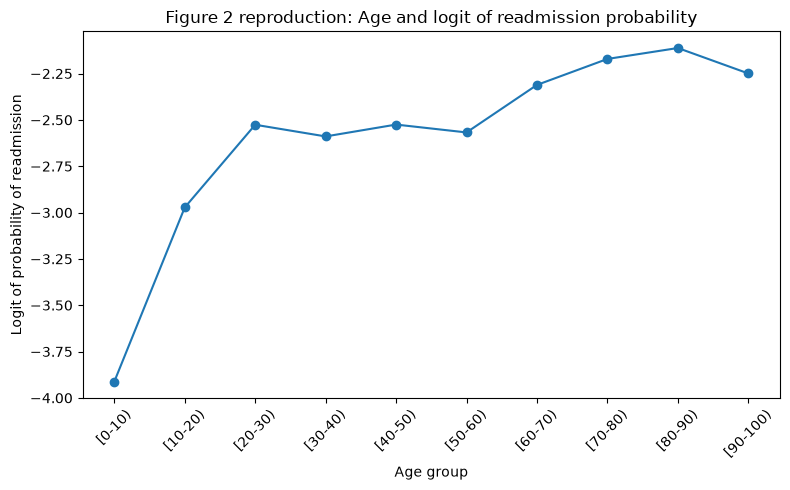

In [44]:
plt.figure(figsize=(8, 5))

plt.plot(
    age_logit["age"],
    age_logit["logit_readmission"],
    marker="o"
)

plt.xlabel("Age group")
plt.ylabel("Logit of probability of readmission")
plt.title("Figure 2 reproduction: Age and logit of readmission probability")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(FIGURE_DIR / "figure2_age_logit_reproduction.png", dpi=300)
plt.show()

## Logistic regression

In [46]:
df_model = df_clean.copy()

df_model["hba1c_group"] = pd.Categorical(
    df_model["hba1c_group"],
    categories=[
        "No test was performed",
        "High, medication changed",
        "High, medication not changed",
        "Normal result of the test"
    ],
    ordered=False
)

df_model["primary_diagnosis"] = pd.Categorical(
    df_model["primary_diagnosis"],
    categories=[
        "Diabetes",
        "Circulatory",
        "Respiratory",
        "Digestive",
        "Injury",
        "Musculoskeletal",
        "Genitourinary",
        "Neoplasms",
        "Other"
    ],
    ordered=False
)

df_model["age_group"] = pd.Categorical(
    df_model["age_group"],
    categories=["30-60", ">60", "<=30"],
    ordered=False
)

df_model["race_group"] = pd.Categorical(
    df_model["race_group"],
    categories=["AfricanAmerican", "Caucasian", "Missing", "Other"],
    ordered=False
)

df_model["admission_source_group"] = pd.Categorical(
    df_model["admission_source_group"],
    categories=["Emergency room", "Other", "Physician/clinic referral"],
    ordered=False
)

df_model["discharge_group"] = pd.Categorical(
    df_model["discharge_group"],
    categories=["Home", "Other"],
    ordered=False
)

df_model["medical_specialty_group"] = pd.Categorical(
    df_model["medical_specialty_group"],
    categories=[
        "Cardiology",
        "Family/General Practice",
        "Internal Medicine",
        "Missing",
        "Other",
        "Surgery"
    ],
    ordered=False
)

In [49]:
formula_final = """
readmitted_30 ~
    C(discharge_group)
    + C(race_group)
    + C(admission_source_group)
    + C(medical_specialty_group)
    + time_in_hospital
    + C(age_group)
    + C(primary_diagnosis)
    + C(hba1c_group)

    + C(discharge_group):C(race_group)
    + C(discharge_group):C(medical_specialty_group)
    + C(discharge_group):C(primary_diagnosis)
    + C(discharge_group):time_in_hospital

    + C(medical_specialty_group):time_in_hospital
    + C(medical_specialty_group):C(age_group)

    + C(primary_diagnosis):time_in_hospital
    + C(primary_diagnosis):C(hba1c_group)
"""

In [50]:
model_final = smf.glm(
    formula=formula_final,
    data=df_model,
    family=sm.families.Binomial()
).fit(maxiter=200)

print(model_final.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:          readmitted_30   No. Observations:                69987
Model:                            GLM   Df Residuals:                    69897
Model Family:                Binomial   Df Model:                           89
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -20640.
Date:                Thu, 09 Jul 2026   Deviance:                       41279.
Time:                        15:42:21   Pearson chi2:                 6.99e+04
No. Iterations:                     7   Pseudo R-squ. (CS):            0.01425
Covariance Type:            nonrobust                                         
                                                                                             coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------

In [67]:
coef_raw = pd.DataFrame({
    "term": model_final.params.index,
    "estimate": model_final.params.values,
    "std_error": model_final.bse.values,
    "z_value": model_final.tvalues.values,
    "p_value": model_final.pvalues.values
})

coef_raw["significant_0_01"] = coef_raw["p_value"] < 0.01

coef_raw.head()

,term,estimate,std_error,z_value,p_value,significant_0_01
0,Intercept,-3.155718,0.175644,-17.966523,3.563638e-72,True
1,C(discharge_group)[T.Other],0.281796,0.194981,1.445248,1.483883e-01,False
2,C(race_group)[T.Caucasian],0.013440,0.048407,0.277636,7.812915e-01,False
3,C(race_group)[T.Missing],-0.317129,0.134048,-2.365780,1.799214e-02,False
4,C(race_group)[T.Other],-0.298442,0.104835,-2.846788,4.416277e-03,True


### Reproduce Table 4 and 5

In [ ]:
table4_non_interaction = coef_raw[
    ~coef_raw["term"].str.contains(":", regex=False)
].copy()

table5_interaction = coef_raw[
    coef_raw["term"].str.contains(":", regex=False)
].copy()

In [ ]:
table4_non_interaction

,term,estimate,std_error,z_value,p_value,significant_0_01
0,Intercept,-3.155718,0.175644,-17.966523,3.563638e-72,True
1,C(discharge_group)[T.Other],0.281796,0.194981,1.445248,1.483883e-01,False
2,C(race_group)[T.Caucasian],0.013440,0.048407,0.277636,7.812915e-01,False
3,C(race_group)[T.Missing],-0.317129,0.134048,-2.365780,1.799214e-02,False
4,C(race_group)[T.Other],-0.298442,0.104835,-2.846788,4.416277e-03,True
5,C(admission_source_group)[T.Other],-0.132272,0.041273,-3.204794,1.351591e-03,True
6,C(admission_source_group)[T.Physician/clinic r...,-0.017885,0.032060,-0.557863,5.769380e-01,False
7,C(medical_specialty_group)[T.Family/General Pr...,0.396831,0.183820,2.158803,3.086547e-02,False
8,C(medical_specialty_group)[T.Internal Medicine],0.388266,0.164348,2.362465,1.815383e-02,False
9,C(medical_specialty_group)[T.Missing],0.409016,0.149414,2.737473,6.191329e-03,True


In [55]:
table5_interaction

,term,estimate,std_error,z_value,p_value,significant_0_01
25,C(discharge_group)[T.Other]:C(race_group)[T.Ca...,0.018844,0.071861,0.262230,0.793144,False
26,C(discharge_group)[T.Other]:C(race_group)[T.Mi...,0.285795,0.188392,1.517018,0.129262,False
27,C(discharge_group)[T.Other]:C(race_group)[T.Ot...,0.497153,0.150654,3.299957,0.000967,True
28,C(discharge_group)[T.Other]:C(medical_specialt...,0.325280,0.180121,1.805893,0.070935,False
29,C(discharge_group)[T.Other]:C(medical_specialt...,0.197330,0.164727,1.197917,0.230949,False
30,C(discharge_group)[T.Other]:C(medical_specialt...,0.245690,0.153958,1.595820,0.110529,False
31,C(discharge_group)[T.Other]:C(medical_specialt...,0.396257,0.165715,2.391201,0.016793,False
32,C(discharge_group)[T.Other]:C(medical_specialt...,0.683892,0.198696,3.441908,0.000578,True
33,C(discharge_group)[T.Other]:C(primary_diagnosi...,-0.021204,0.111241,-0.190616,0.848826,False
34,C(discharge_group)[T.Other]:C(primary_diagnosi...,0.108631,0.129564,0.838435,0.401787,False


In [56]:
table4_non_interaction.to_csv(
    TABLE_DIR / "table4_logistic_non_interaction_terms.csv",
    index=False
)

table5_interaction.to_csv(
    TABLE_DIR / "table5_logistic_interaction_terms.csv",
    index=False
)

In [69]:
def format_p_value(p):
    if pd.isna(p):
        return ""
    elif p < 2e-16:
        return "<2e-16"
    elif p < 0.001:
        return "<0.001"
    else:
        return f"{p:.3f}"


def format_estimate(x):
    if pd.isna(x):
        return ""
    return f"{x:.3f}"


variable_display_map = {
    "discharge_group": "Discharge",
    "race_group": "Race",
    "admission_source_group": "Admission",
    "medical_specialty_group": "Medical specialty",
    "time_in_hospital": "Time in hospital",
    "age_group": "Age",
    "primary_diagnosis": "Diagnosis",
    "hba1c_group": "HbA1c"
}

value_display_map = {
    "discharge_group": {
        "Home": "Home",
        "Other": "Other"
    },
    "race_group": {
        "AfricanAmerican": "African American",
        "Caucasian": "Caucasian",
        "Missing": "Missing",
        "Other": "Other"
    },
    "admission_source_group": {
        "Emergency room": "Emergency",
        "Other": "Other",
        "Physician/clinic referral": "referral"
    },
    "medical_specialty_group": {
        "Cardiology": "Cardiology",
        "Family/General Practice": "General practice",
        "Internal Medicine": "Internal medicine",
        "Missing": "Missing",
        "Other": "Other",
        "Surgery": "Surgery"
    },
    "age_group": {
        "30-60": "[30, 60)",
        ">60": "[60, 100)",
        "<=30": "<30"
    },
    "primary_diagnosis": {
        "Diabetes": "Diabetes",
        "Circulatory": "Circulatory",
        "Digestive": "Digestive",
        "Genitourinary": "Genitourinary",
        "Injury": "Injury",
        "Musculoskeletal": "Musculoskeletal",
        "Neoplasms": "Neoplasms",
        "Other": "Other",
        "Respiratory": "Respiratory"
    },
    "hba1c_group": {
        "No test was performed": "Not measured",
        "High, medication changed": "High, changed",
        "High, medication not changed": "High, not changed",
        "Normal result of the test": "Normal"
    }
}


def display_variable(var):
    return variable_display_map.get(var, var)


def display_value(var, value):
    return value_display_map.get(var, {}).get(value, value)

In [70]:
coef_lookup = coef_raw.set_index("term")

missing_terms = []

def get_coef_row(attribute, value, term=None, reference=False):
    if reference:
        return {
            "Attribute name": attribute,
            "Value": value,
            "Estimate": "Reference",
            "P value": "",
            "Significant at 0.01": ""
        }

    if term not in coef_lookup.index:
        missing_terms.append(term)
        return {
            "Attribute name": attribute,
            "Value": value,
            "Estimate": "",
            "P value": "",
            "Significant at 0.01": ""
        }

    estimate = coef_lookup.loc[term, "estimate"]
    p_value = coef_lookup.loc[term, "p_value"]
    significant = p_value < 0.01

    value_display = f"{value}*" if significant else value

    return {
        "Attribute name": attribute,
        "Value": value_display,
        "Estimate": format_estimate(estimate),
        "P value": format_p_value(p_value),
        "Significant at 0.01": "Yes" if significant else "No"
    }


def categorical_term(variable, value):
    return f"C({variable})[T.{value}]"

In [71]:
table4_rows = []

# Intercept
table4_rows.append(
    get_coef_row(
        attribute="Intercept",
        value="",
        term="Intercept"
    )
)

# Discharge
table4_rows.append(get_coef_row("Discharge", "Home", reference=True))
table4_rows.append(get_coef_row("Discharge", "Other", categorical_term("discharge_group", "Other")))

# Race
table4_rows.append(get_coef_row("Race", "African American", reference=True))
table4_rows.append(get_coef_row("Race", "Caucasian", categorical_term("race_group", "Caucasian")))
table4_rows.append(get_coef_row("Race", "Missing", categorical_term("race_group", "Missing")))
table4_rows.append(get_coef_row("Race", "Other", categorical_term("race_group", "Other")))

# Admission
table4_rows.append(get_coef_row("Admission", "Emergency", reference=True))
table4_rows.append(get_coef_row("Admission", "Other", categorical_term("admission_source_group", "Other")))
table4_rows.append(get_coef_row("Admission", "referral", categorical_term("admission_source_group", "Physician/clinic referral")))

# Medical specialty
table4_rows.append(get_coef_row("Medical specialty", "Cardiology", reference=True))
table4_rows.append(get_coef_row("Medical specialty", "General practice", categorical_term("medical_specialty_group", "Family/General Practice")))
table4_rows.append(get_coef_row("Medical specialty", "Internal medicine", categorical_term("medical_specialty_group", "Internal Medicine")))
table4_rows.append(get_coef_row("Medical specialty", "Missing", categorical_term("medical_specialty_group", "Missing")))
table4_rows.append(get_coef_row("Medical specialty", "Other", categorical_term("medical_specialty_group", "Other")))
table4_rows.append(get_coef_row("Medical specialty", "Surgery", categorical_term("medical_specialty_group", "Surgery")))

# Time in hospital
table4_rows.append(get_coef_row("Time in hospital", "", "time_in_hospital"))

# Age
table4_rows.append(get_coef_row("Age", "[30, 60)", reference=True))
table4_rows.append(get_coef_row("Age", "[60, 100)", categorical_term("age_group", ">60")))
table4_rows.append(get_coef_row("Age", "<30", categorical_term("age_group", "<=30")))

# Diagnosis
table4_rows.append(get_coef_row("Diagnosis", "Diabetes", reference=True))
table4_rows.append(get_coef_row("Diagnosis", "Circulatory", categorical_term("primary_diagnosis", "Circulatory")))
table4_rows.append(get_coef_row("Diagnosis", "Digestive", categorical_term("primary_diagnosis", "Digestive")))
table4_rows.append(get_coef_row("Diagnosis", "Genitourinary", categorical_term("primary_diagnosis", "Genitourinary")))
table4_rows.append(get_coef_row("Diagnosis", "Injury", categorical_term("primary_diagnosis", "Injury")))
table4_rows.append(get_coef_row("Diagnosis", "Musculoskeletal", categorical_term("primary_diagnosis", "Musculoskeletal")))
table4_rows.append(get_coef_row("Diagnosis", "Neoplasms", categorical_term("primary_diagnosis", "Neoplasms")))
table4_rows.append(get_coef_row("Diagnosis", "Other", categorical_term("primary_diagnosis", "Other")))
table4_rows.append(get_coef_row("Diagnosis", "Respiratory", categorical_term("primary_diagnosis", "Respiratory")))

# HbA1c
table4_rows.append(get_coef_row("HbA1c", "Not measured", reference=True))
table4_rows.append(get_coef_row("HbA1c", "High, changed", categorical_term("hba1c_group", "High, medication changed")))
table4_rows.append(get_coef_row("HbA1c", "High, not changed", categorical_term("hba1c_group", "High, medication not changed")))
table4_rows.append(get_coef_row("HbA1c", "Normal", categorical_term("hba1c_group", "Normal result of the test")))

table4_polished = pd.DataFrame(table4_rows)

# Blank repeated attribute names for paper-like display
table4_display = table4_polished.copy()
table4_display["Attribute name"] = table4_display["Attribute name"].mask(
    table4_display["Attribute name"].duplicated(),
    ""
)

display(table4_display)

,Attribute name,Value,Estimate,P value,Significant at 0.01
0,Intercept,*,-3.156,<2e-16,Yes
1,Discharge,Home,Reference,,
2,,Other,0.282,0.148,No
3,Race,African American,Reference,,
4,,Caucasian,0.013,0.781,No
5,,Missing,-0.317,0.018,No
6,,Other*,-0.298,0.004,Yes
7,Admission,Emergency,Reference,,
8,,Other*,-0.132,0.001,Yes
9,,referral,-0.018,0.577,No


In [72]:
def parse_term_component(component):
    """
    Parse one component of a statsmodels term.
    Example:
    C(primary_diagnosis)[T.Circulatory]
    time_in_hospital
    """

    if component == "time_in_hospital":
        return "time_in_hospital", ""

    match = re.match(r"C\((.*?)\)\[T\.(.*)\]", component)

    if match:
        variable = match.group(1)
        value = match.group(2)
        return variable, value

    return component, ""


def interaction_sort_group(var1, var2):
    var_set = {var1, var2}

    sort_order = {
        frozenset(["age_group", "medical_specialty_group"]): 1,
        frozenset(["primary_diagnosis", "discharge_group"]): 2,
        frozenset(["race_group", "discharge_group"]): 3,
        frozenset(["discharge_group", "time_in_hospital"]): 4,
        frozenset(["medical_specialty_group", "discharge_group"]): 5,
        frozenset(["medical_specialty_group", "time_in_hospital"]): 6,
        frozenset(["primary_diagnosis", "time_in_hospital"]): 7,
        frozenset(["primary_diagnosis", "hba1c_group"]): 8
    }

    return sort_order.get(frozenset(var_set), 99)

In [73]:
interaction_rows = []

interaction_coef = coef_raw[
    coef_raw["term"].str.contains(":", regex=False)
].copy()

for _, row in interaction_coef.iterrows():
    term = row["term"]
    components = term.split(":")

    if len(components) != 2:
        continue

    var1, value1 = parse_term_component(components[0])
    var2, value2 = parse_term_component(components[1])

    p_value = row["p_value"]
    significant = p_value < 0.01

    interaction_rows.append({
        "sort_group": interaction_sort_group(var1, var2),
        "term": term,

        "Attribute name": display_variable(var1),
        "Value": display_value(var1, value1),

        "Interaction attribute": display_variable(var2),
        "Interaction value": display_value(var2, value2),

        "Estimate": format_estimate(row["estimate"]),
        "P value": format_p_value(p_value),
        "Significant at 0.01": "Yes" if significant else "No"
    })

table5_polished = pd.DataFrame(interaction_rows)

table5_polished = table5_polished.sort_values(
    ["sort_group", "Attribute name", "Value", "Interaction attribute", "Interaction value"]
).drop(columns=["sort_group", "term"])

display(table5_polished)

,Attribute name,Value,Interaction attribute,Interaction value,Estimate,P value,Significant at 0.01
21,Medical specialty,General practice,Age,<30,-2.478,0.013,No
16,Medical specialty,General practice,Age,"[60, 100)",0.075,0.676,No
22,Medical specialty,Internal medicine,Age,<30,-2.002,0.026,No
17,Medical specialty,Internal medicine,Age,"[60, 100)",-0.003,0.987,No
23,Medical specialty,Missing,Age,<30,-1.450,0.091,No
18,Medical specialty,Missing,Age,"[60, 100)",-0.082,0.579,No
24,Medical specialty,Other,Age,<30,-2.395,0.006,Yes
19,Medical specialty,Other,Age,"[60, 100)",-0.107,0.499,No
25,Medical specialty,Surgery,Age,<30,-2.964,0.026,No
20,Medical specialty,Surgery,Age,"[60, 100)",-0.144,0.466,No


In [74]:
table4_polished.to_csv(
    TABLE_DIR / "table4_polished_non_interaction_terms.csv",
    index=False
)

table4_display.to_csv(
    TABLE_DIR / "table4_display_style_non_interaction_terms.csv",
    index=False
)       
        
table5_polished.to_csv(
    TABLE_DIR / "table5_polished_interaction_terms.csv",
    index=False
)

if missing_terms:
    print("Missing terms, check naming/reference categories:")
    for term in missing_terms:
        print(term)

### Reproduce Figure 1

In [57]:
mean_time = df_model["time_in_hospital"].mean()

fig1_grid = pd.DataFrame([
    {
        "hba1c_group": hba1c,
        "primary_diagnosis": diag,
        "discharge_group": "Home",
        "race_group": "AfricanAmerican",
        "admission_source_group": "Emergency room",
        "medical_specialty_group": "Cardiology",
        "age_group": "30-60",
        "time_in_hospital": mean_time
    }
    for diag in ["Diabetes", "Respiratory", "Circulatory"]
    for hba1c in [
        "No test was performed",
        "Normal result of the test",
        "High, medication changed",
        "High, medication not changed"
    ]
])

In [58]:
pred = model_final.get_prediction(fig1_grid).summary_frame(alpha=0.05)

fig1_grid["predicted_probability"] = pred["mean"]
fig1_grid["ci_lower"] = pred["mean_ci_lower"]
fig1_grid["ci_upper"] = pred["mean_ci_upper"]

fig1_grid

,hba1c_group,primary_diagnosis,discharge_group,race_group,admission_source_group,medical_specialty_group,age_group,time_in_hospital,predicted_probability,ci_lower,ci_upper
0,No test was performed,Diabetes,Home,AfricanAmerican,Emergency room,Cardiology,30-60,4.273336,0.069007,0.052218,0.090677
1,Normal result of the test,Diabetes,Home,AfricanAmerican,Emergency room,Cardiology,30-60,4.273336,0.069728,0.048367,0.099535
2,"High, medication changed",Diabetes,Home,AfricanAmerican,Emergency room,Cardiology,30-60,4.273336,0.047566,0.033308,0.067502
3,"High, medication not changed",Diabetes,Home,AfricanAmerican,Emergency room,Cardiology,30-60,4.273336,0.041799,0.025929,0.066716
4,No test was performed,Respiratory,Home,AfricanAmerican,Emergency room,Cardiology,30-60,4.273336,0.049366,0.037755,0.064310
5,Normal result of the test,Respiratory,Home,AfricanAmerican,Emergency room,Cardiology,30-60,4.273336,0.031073,0.021369,0.044980
6,"High, medication changed",Respiratory,Home,AfricanAmerican,Emergency room,Cardiology,30-60,4.273336,0.046214,0.030319,0.069843
7,"High, medication not changed",Respiratory,Home,AfricanAmerican,Emergency room,Cardiology,30-60,4.273336,0.041870,0.024336,0.071119
8,No test was performed,Circulatory,Home,AfricanAmerican,Emergency room,Cardiology,30-60,4.273336,0.066187,0.051844,0.084146
9,Normal result of the test,Circulatory,Home,AfricanAmerican,Emergency room,Cardiology,30-60,4.273336,0.063390,0.048157,0.083020


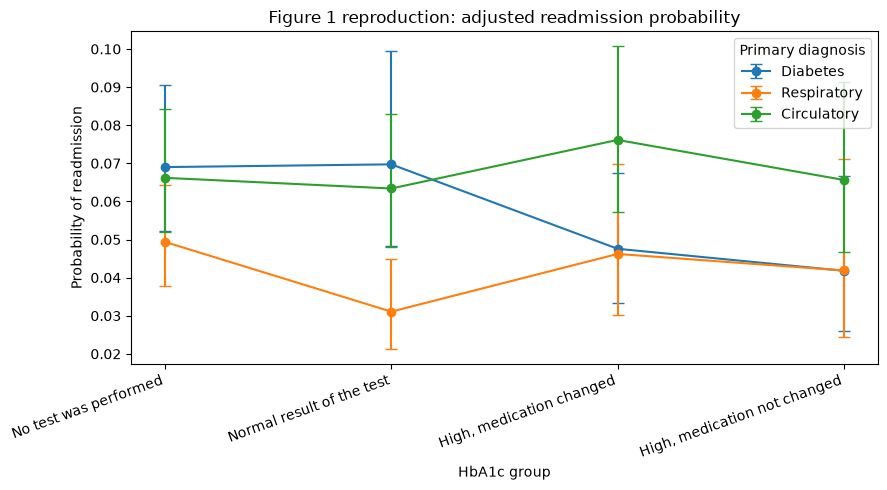

In [59]:
hba1c_plot_order = [
    "No test was performed",
    "Normal result of the test",
    "High, medication changed",
    "High, medication not changed"
]

plt.figure(figsize=(9, 5))

for diag in ["Diabetes", "Respiratory", "Circulatory"]:
    sub = fig1_grid[fig1_grid["primary_diagnosis"] == diag].copy()
    sub["hba1c_group"] = pd.Categorical(
        sub["hba1c_group"],
        categories=hba1c_plot_order,
        ordered=True
    )
    sub = sub.sort_values("hba1c_group")

    plt.errorbar(
        sub["hba1c_group"],
        sub["predicted_probability"],
        yerr=[
            sub["predicted_probability"] - sub["ci_lower"],
            sub["ci_upper"] - sub["predicted_probability"]
        ],
        marker="o",
        capsize=4,
        label=diag
    )

plt.xlabel("HbA1c group")
plt.ylabel("Probability of readmission")
plt.title("Figure 1 reproduction: adjusted readmission probability")
plt.xticks(rotation=20, ha="right")
plt.legend(title="Primary diagnosis")
plt.tight_layout()

plt.savefig(FIGURE_DIR / "figure1_adjusted_readmission_probability.png", dpi=300)
plt.show()

### Reproduce Figure 3

In [62]:
# HbA1c order used in the paper's x-axis
hba1c_order_model = [
    "No test was performed",
    "Normal result of the test",
    "High, medication changed",
    "High, medication not changed"
]

hba1c_order_display = [
    "None",
    "Normal",
    "High, med.\nchanged",
    "High, med.\nnot changed"
]

# Paper-style diagnosis groups in Figure 3
fig3_panel_a = [
    "Diabetes",
    "Other",
    "Digestive",
    "Respiratory",
    "Circulatory"
]

fig3_panel_b = [
    "Diabetes",
    "Genitourinary",
    "Injury",
    "Musculoskeletal",
    "Neoplasms"
]

# Display labels to match the paper legend more closely
diagnosis_display_map = {
    "Diabetes": "Diabetes",
    "Other": "Other",
    "Digestive": "Digestive",
    "Respiratory": "Respiratory",
    "Circulatory": "Circulatory",
    "Genitourinary": "Genitourinary",
    "Injury": "Injury",
    "Musculoskeletal": "Musculoskelet",
    "Neoplasms": "Neoplasms"
}

mean_time = df_model["time_in_hospital"].mean()

In [63]:
def make_prediction_grid(diagnosis_groups):
    rows = []

    for diag in diagnosis_groups:
        for hba1c in hba1c_order_model:
            rows.append({
                "hba1c_group": hba1c,
                "primary_diagnosis": diag,

                # Reference values used for adjusted prediction
                "discharge_group": "Home",
                "race_group": "AfricanAmerican",
                "admission_source_group": "Emergency room",
                "medical_specialty_group": "Cardiology",
                "age_group": "30-60",
                "time_in_hospital": mean_time
            })

    return pd.DataFrame(rows)

In [64]:
def add_predictions(grid, model):
    pred = model.get_prediction(grid).summary_frame(alpha=0.05)

    grid = grid.copy()
    grid["predicted_probability"] = pred["mean"]
    grid["ci_lower"] = pred["mean_ci_lower"]
    grid["ci_upper"] = pred["mean_ci_upper"]

    return grid


fig3_data_a = add_predictions(make_prediction_grid(fig3_panel_a), model_final)
fig3_data_b = add_predictions(make_prediction_grid(fig3_panel_b), model_final)

fig3_data = pd.concat([fig3_data_a, fig3_data_b], ignore_index=True)

fig3_data.to_csv(
    FIGURE_DIR / "figure3_prediction_data.csv",
    index=False
)

fig3_data.head()

,hba1c_group,primary_diagnosis,discharge_group,race_group,admission_source_group,medical_specialty_group,age_group,time_in_hospital,predicted_probability,ci_lower,ci_upper
0,No test was performed,Diabetes,Home,AfricanAmerican,Emergency room,Cardiology,30-60,4.273336,0.069007,0.052218,0.090677
1,Normal result of the test,Diabetes,Home,AfricanAmerican,Emergency room,Cardiology,30-60,4.273336,0.069728,0.048367,0.099535
2,"High, medication changed",Diabetes,Home,AfricanAmerican,Emergency room,Cardiology,30-60,4.273336,0.047566,0.033308,0.067502
3,"High, medication not changed",Diabetes,Home,AfricanAmerican,Emergency room,Cardiology,30-60,4.273336,0.041799,0.025929,0.066716
4,No test was performed,Other,Home,AfricanAmerican,Emergency room,Cardiology,30-60,4.273336,0.056165,0.043075,0.072930


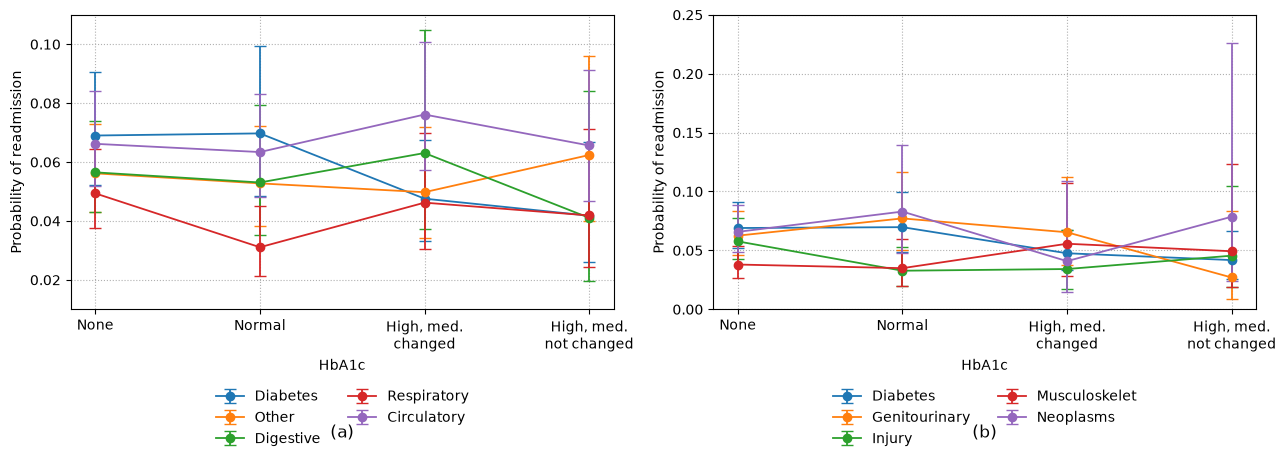

In [65]:
x = np.arange(len(hba1c_order_model))

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True)

def plot_fig3_panel(ax, data, diagnosis_groups, panel_label, ylim):
    for diag in diagnosis_groups:
        sub = data[data["primary_diagnosis"] == diag].copy()

        sub["hba1c_group"] = pd.Categorical(
            sub["hba1c_group"],
            categories=hba1c_order_model,
            ordered=True
        )

        sub = sub.sort_values("hba1c_group")

        y = sub["predicted_probability"].to_numpy()
        yerr_lower = y - sub["ci_lower"].to_numpy()
        yerr_upper = sub["ci_upper"].to_numpy() - y

        ax.errorbar(
            x,
            y,
            yerr=[yerr_lower, yerr_upper],
            marker="o",
            capsize=4,
            linewidth=1.3,
            label=diagnosis_display_map.get(diag, diag)
        )

    ax.set_xticks(x)
    ax.set_xticklabels(hba1c_order_display, fontsize=10)
    ax.set_xlabel("HbA1c")
    ax.set_ylabel("Probability of readmission")
    ax.set_ylim(*ylim)
    ax.grid(True, linestyle=":", linewidth=0.8)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.23), ncol=2, frameon=False)
    ax.text(0.5, -0.42, f"({panel_label})", transform=ax.transAxes,
            ha="center", va="center", fontsize=12)


plot_fig3_panel(
    axes[0],
    fig3_data_a,
    fig3_panel_a,
    panel_label="a",
    ylim=(0.01, 0.11)
)

plot_fig3_panel(
    axes[1],
    fig3_data_b,
    fig3_panel_b,
    panel_label="b",
    ylim=(0.00, 0.25)
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "figure3_reproduction_paper_style.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()